In [25]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import string
# Set working directory to project root
if os.path.basename(os.getcwd()) == "Figures":
    os.chdir("..")
print("Working directory:", os.getcwd())



Working directory: c:\BioCro_DSSAT_WOFOST_Egorov_etal_paper-main


In [26]:
# ---------------------------------------------------------------------------
# Data paths
# ---------------------------------------------------------------------------

# ---------------------------------------------------------------------------
# Data paths (all relative to data/ subdirectory)
# ---------------------------------------------------------------------------
_nb_dir  = os.path.dirname(os.path.abspath('__file__'))
DATA_ROOT = os.path.normpath(os.path.join(_nb_dir , 'data'))
FIG_S2 = "./data/fig_S2"

OBS_LAI_PATTERN = f'{FIG_S2}/obs_lai/LAI_point-*.csv'
OBS_AGB_PATTERN = f'{FIG_S2}/obs_AGB/AGB_point-*.csv'
OBS_ET_PATTERN  = f'{FIG_S2}/obs_ET/ET_point-*.csv'
OBS_SWC_PATTERN = f'{FIG_S2}/obs_swc_S/SWC_point-*.csv'

BIOCRO_PATTERN  = f'{FIG_S2}/biocro/US-NE*-*-Soybean-BioCro.csv'
DSSAT_PATTERN   = f'{FIG_S2}/DSSAT/US-NE*-DSSAT_*.csv'
WOFOST_PATTERN  = f'{FIG_S2}/wofrst/US-NE*-*-WOFOST.csv'

# ---------------------------------------------------------------------------
# Plot styling
# ---------------------------------------------------------------------------
COLOR_BIOCRO = 'blue'
COLOR_DSSAT  = 'magenta'
COLOR_WOFOST = 'lime'
LINE_WIDTH   = 1.4

# Verify files exist
for label, pat in [('LAI obs', OBS_LAI_PATTERN), ('AGB obs', OBS_AGB_PATTERN),
                   ('ET obs', OBS_ET_PATTERN), ('SWC obs', OBS_SWC_PATTERN),
                   ('BioCro', BIOCRO_PATTERN), ('DSSAT', DSSAT_PATTERN),
                   ('WOFOST', WOFOST_PATTERN)]:
    n = len(glob.glob(pat))
    print(f"  {label}: {n} files")

  LAI obs: 4 files
  AGB obs: 4 files
  ET obs: 4 files
  SWC obs: 4 files
  BioCro: 4 files
  DSSAT: 4 files
  WOFOST: 4 files


In [27]:
def plot_variable(obs_pattern, obs_date_col, obs_val_col,
                  biocro_col, dssat_col, wofost_col,
                  ylabel, ylim_max=None,
                  biocro_scale=1.0, dssat_scale=1.0, wofost_scale=1.0,
                  wofost_sum_cols=None,
                  obs_dayfirst=False,
                  obs_style='scatter', obs_marker_size=50,
                  obs_fill_cols=None,
                  model_lw=LINE_WIDTH):
    """
    Plot observed vs modeled timeseries (BioCro, DSSAT, WOFOST) for each site-year.

    Parameters
    ----------
    obs_pattern     : glob pattern for observed CSV files.
    obs_date_col    : date column name in observed CSV.
    obs_val_col     : value column name in observed CSV.
    biocro_col      : value column in BioCro CSV.
    dssat_col       : value column in DSSAT CSV.
    wofost_col      : value column in WOFOST CSV (ignored if wofost_sum_cols set).
    ylabel          : y-axis label.
    ylim_max        : upper y-axis limit (None = auto).
    *_scale         : multiplicative scale factor for each model.
    wofost_sum_cols : list of columns to sum for WOFOST value (e.g. ['TRA','EVS']).
    obs_dayfirst    : parse observed dates with dayfirst=True.
    obs_style       : 'scatter' or 'line'.
    obs_marker_size : marker size for scatter obs.
    obs_fill_cols   : tuple (min_col, max_col) for fill_between on obs.
    model_lw        : line width for model lines.
    """
    OBS_PATHS    = sorted(glob.glob(obs_pattern))
    BIOCRO_PATHS = sorted(glob.glob(BIOCRO_PATTERN))
    DSSAT_PATHS  = sorted(glob.glob(DSSAT_PATTERN))
    WOFOST_PATHS = sorted(glob.glob(WOFOST_PATTERN))

    n = len(OBS_PATHS)
    fig, axes = plt.subplots(nrows=n, ncols=1, figsize=(2.6, 2.5 * n))
    if n == 1:
        axes = [axes]

    for i, obs_path in enumerate(OBS_PATHS):
        # Extract site + year from filename
        parts = os.path.basename(obs_path).replace('.csv', '').split('-')
        site = f"{parts[1].strip()} {parts[2].strip()}"
        year = parts[-1].strip()

        # --- Observed ---
        obs = pd.read_csv(obs_path)
        obs[obs_date_col] = pd.to_datetime(obs[obs_date_col],
                                           dayfirst=obs_dayfirst, errors='coerce')
        obs['DOY'] = obs[obs_date_col].dt.dayofyear

        # --- BioCro ---
        bc = pd.read_csv(BIOCRO_PATHS[i])
        bc['date'] = pd.to_datetime(bc['date'])
        bc['DOY'] = bc['date'].dt.dayofyear

        # --- DSSAT ---
        ds = pd.read_csv(DSSAT_PATHS[i])
        ds['Date'] = pd.to_datetime(ds['Date'])
        ds['DOY'] = ds['Date'].dt.dayofyear

        # --- WOFOST ---
        wo = pd.read_csv(WOFOST_PATHS[i])
        wo['day'] = pd.to_datetime(wo['day'])
        wo['DOY'] = wo['day'].dt.dayofyear

        if wofost_sum_cols:
            wo_val = sum(wo[c] for c in wofost_sum_cols) * wofost_scale
        else:
            wo_val = wo[wofost_col] * wofost_scale

        # --- Plot ---
        ax = axes[i]

        # Observed
        if obs_style == 'scatter':
            ax.scatter(obs['DOY'], obs[obs_val_col],
                       edgecolor='black', facecolor='none', marker='o',
                       s=obs_marker_size, label='Observed', zorder=3)
        else:  # line
            ax.plot(obs['DOY'], obs[obs_val_col], color='black',
                    label='Observed', linewidth=2.5)
            if obs_fill_cols:
                ax.fill_between(obs['DOY'], obs[obs_fill_cols[0]],
                                obs[obs_fill_cols[1]],
                                color='black', alpha=0.3, zorder=5)

        # Models
        ax.plot(bc['DOY'], bc[biocro_col] * biocro_scale,
                color=COLOR_BIOCRO, label='BioCro', linewidth=model_lw)
        ax.plot(ds['DOY'], ds[dssat_col] * dssat_scale,
                color=COLOR_DSSAT, label='DSSAT', linewidth=model_lw)
        ax.plot(wo['DOY'], wo_val,
                color=COLOR_WOFOST, label='WOFOST', linewidth=model_lw)

        ax.set_xlabel('Day of Year (DOY)')
        ax.set_ylabel(ylabel)
        ax.set_title(f'{site.upper()} {year}')
        ax.set_xlim(140, 300)
        if ylim_max is not None:
            ax.set_ylim(0, ylim_max)
        ax.grid(False)

    plt.tight_layout()
    plt.show()

C:\Users\yaron\AppData\Local\Temp\ipykernel_31800\3817952355.py:49: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  obs[obs_date_col] = pd.to_datetime(obs[obs_date_col],
C:\Users\yaron\AppData\Local\Temp\ipykernel_31800\3817952355.py:49: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  obs[obs_date_col] = pd.to_datetime(obs[obs_date_col],


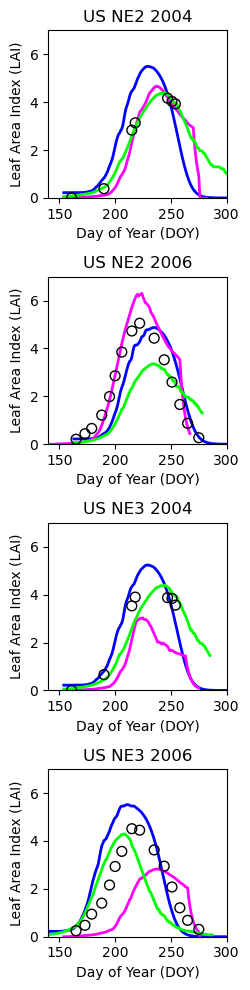

In [28]:
# ---------------------------------------------------------------------------
# LAI — Leaf Area Index
# ---------------------------------------------------------------------------
plot_variable(
    obs_pattern=OBS_LAI_PATTERN,
    obs_date_col='Date', obs_val_col='Real_LAI',
    biocro_col='LAI', dssat_col='LAID', wofost_col='LAI',
    ylabel='Leaf Area Index (LAI)', ylim_max=7,
    obs_dayfirst=True, obs_marker_size=50, model_lw=2
)

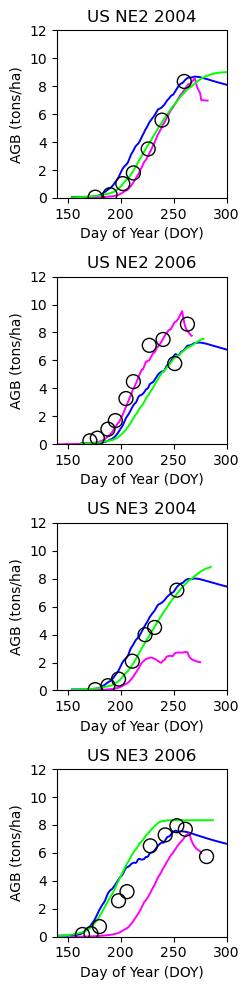

In [29]:
# ---------------------------------------------------------------------------
# AGB — Above-Ground Biomass
# ---------------------------------------------------------------------------
plot_variable(
    obs_pattern=OBS_AGB_PATTERN,
    obs_date_col='Date', obs_val_col='Real_AGB',
    biocro_col='AGB', dssat_col='AGB', wofost_col='TAGP',
    ylabel='AGB (tons/ha)', ylim_max=12,
    obs_dayfirst=True, obs_marker_size=100,
    dssat_scale=0.001, wofost_scale=0.001
)

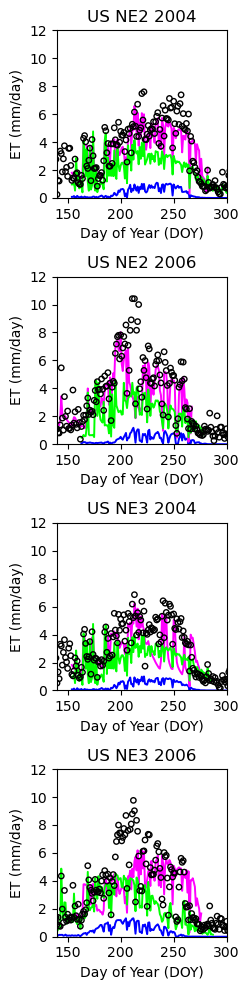

In [30]:
# ---------------------------------------------------------------------------
# ET — Evapotranspiration
# ---------------------------------------------------------------------------
plot_variable(
    obs_pattern=OBS_ET_PATTERN,
    obs_date_col='date', obs_val_col='ET_corr',
    biocro_col='ET', dssat_col='ET', wofost_col=None,
    wofost_sum_cols=['TRA', 'EVS'], wofost_scale=10.0,
    ylabel='ET (mm/day)', ylim_max=12,
    obs_marker_size=15
)

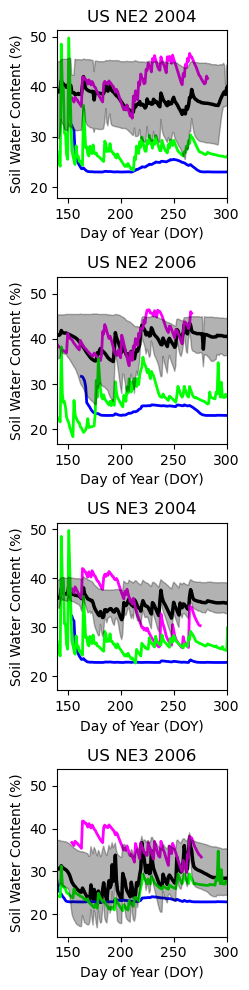

In [31]:
# ---------------------------------------------------------------------------
# SWC — Soil Water Content
# ---------------------------------------------------------------------------
plot_variable(
    obs_pattern=OBS_SWC_PATTERN,
    obs_date_col='DATE', obs_val_col='mean_SWC',
    biocro_col='soil_water_content', dssat_col='SW_Mean', wofost_col='SM',
    ylabel='Soil Water Content (%)', ylim_max=None,
    biocro_scale=100, dssat_scale=100, wofost_scale=100,
    obs_style='line', obs_fill_cols=('MIN_SWC', 'MAX_SWC'),
    model_lw=2
)

C:\Users\yaron\AppData\Local\Temp\ipykernel_31800\2255655680.py:62: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  obs[cfg['obs_date_col']] = pd.to_datetime(
C:\Users\yaron\AppData\Local\Temp\ipykernel_31800\2255655680.py:62: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  obs[cfg['obs_date_col']] = pd.to_datetime(


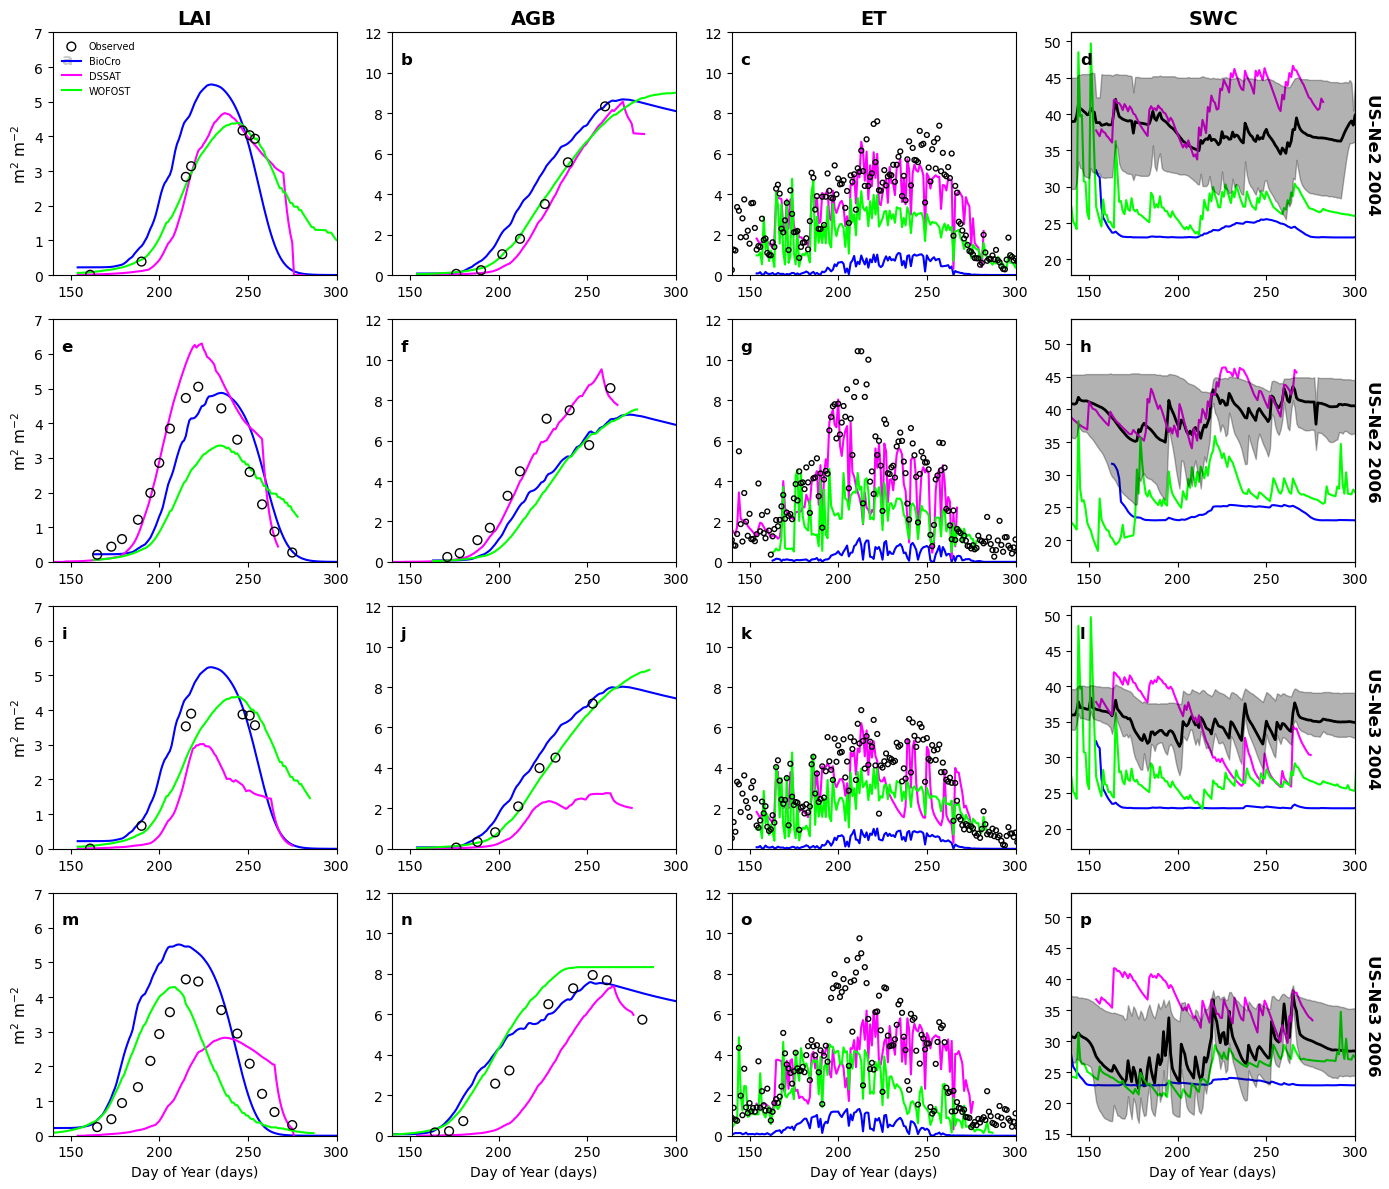

Saved Figures/FIG_S2_combined.png


In [32]:
# ---------------------------------------------------------------------------
# Combined 4×4 figure  (rows = site-years, cols = LAI / AGB / ET / SWC)
# ---------------------------------------------------------------------------


# Variable configs: (obs_pattern, obs_date_col, obs_val_col, biocro_col,
#   dssat_col, wofost_col, wofost_sum_cols, ylabel, ylim_max,
#   biocro_scale, dssat_scale, wofost_scale, obs_dayfirst,
#   obs_style, obs_marker_size, obs_fill_cols, model_lw)
VARIABLES = [
    dict(obs_pattern=OBS_LAI_PATTERN, obs_date_col='Date', obs_val_col='Real_LAI',
         biocro_col='LAI', dssat_col='LAID', wofost_col='LAI',
         wofost_sum_cols=None, ylabel='m$^2$ m$^{-2}$', ylim_max=7,
         biocro_scale=1, dssat_scale=1, wofost_scale=1,
         obs_dayfirst=True, obs_style='scatter', obs_marker_size=40,
         obs_fill_cols=None, model_lw=1.5),
    dict(obs_pattern=OBS_AGB_PATTERN, obs_date_col='Date', obs_val_col='Real_AGB',
         biocro_col='AGB', dssat_col='AGB', wofost_col='TAGP',
         wofost_sum_cols=None, ylabel='tons ha$^{-1}$', ylim_max=12,
         biocro_scale=1, dssat_scale=0.001, wofost_scale=0.001,
         obs_dayfirst=True, obs_style='scatter', obs_marker_size=40,
         obs_fill_cols=None, model_lw=1.5),
    dict(obs_pattern=OBS_ET_PATTERN, obs_date_col='date', obs_val_col='ET_corr',
         biocro_col='ET', dssat_col='ET', wofost_col=None,
         wofost_sum_cols=['TRA', 'EVS'], ylabel='mm d$^{-1}$', ylim_max=12,
         biocro_scale=1, dssat_scale=1, wofost_scale=10.0,
         obs_dayfirst=False, obs_style='scatter', obs_marker_size=12,
         obs_fill_cols=None, model_lw=1.5),
    dict(obs_pattern=OBS_SWC_PATTERN, obs_date_col='DATE', obs_val_col='mean_SWC',
         biocro_col='soil_water_content', dssat_col='SW_Mean', wofost_col='SM',
         wofost_sum_cols=None, ylabel='%', ylim_max=None,
         biocro_scale=100, dssat_scale=100, wofost_scale=100,
         obs_dayfirst=False, obs_style='line', obs_marker_size=50,
         obs_fill_cols=('MIN_SWC', 'MAX_SWC'), model_lw=1.5),
]

COL_TITLES = ['LAI', 'AGB', 'ET', 'SWC']
NROWS = 4  # site-years
NCOLS = 4  # variables

BIOCRO_PATHS = sorted(glob.glob(BIOCRO_PATTERN))
DSSAT_PATHS  = sorted(glob.glob(DSSAT_PATTERN))
WOFOST_PATHS = sorted(glob.glob(WOFOST_PATTERN))

fig, axes = plt.subplots(NROWS, NCOLS, figsize=(14, 12))
letters = list(string.ascii_lowercase)  # a, b, c, ...

for col_idx, cfg in enumerate(VARIABLES):
    OBS_PATHS = sorted(glob.glob(cfg['obs_pattern']))

    for row_idx, obs_path in enumerate(OBS_PATHS):
        ax = axes[row_idx, col_idx]
        panel_label = letters[row_idx * NCOLS + col_idx]

        # Site + year from filename
        parts = os.path.basename(obs_path).replace('.csv', '').split('-')
        site = f"{parts[1].strip()} {parts[2].strip()}"
        year = parts[-1].strip()

        # --- Load observed ---
        obs = pd.read_csv(obs_path)
        obs[cfg['obs_date_col']] = pd.to_datetime(
            obs[cfg['obs_date_col']], dayfirst=cfg['obs_dayfirst'], errors='coerce')
        obs['DOY'] = obs[cfg['obs_date_col']].dt.dayofyear

        # --- Load models ---
        bc = pd.read_csv(BIOCRO_PATHS[row_idx])
        bc['date'] = pd.to_datetime(bc['date'])
        bc['DOY'] = bc['date'].dt.dayofyear

        ds = pd.read_csv(DSSAT_PATHS[row_idx])
        ds['Date'] = pd.to_datetime(ds['Date'])
        ds['DOY'] = ds['Date'].dt.dayofyear

        wo = pd.read_csv(WOFOST_PATHS[row_idx])
        wo['day'] = pd.to_datetime(wo['day'])
        wo['DOY'] = wo['day'].dt.dayofyear

        if cfg['wofost_sum_cols']:
            wo_val = sum(wo[c] for c in cfg['wofost_sum_cols']) * cfg['wofost_scale']
        else:
            wo_val = wo[cfg['wofost_col']] * cfg['wofost_scale']

        # --- Plot observed ---
        if cfg['obs_style'] == 'scatter':
            ax.scatter(obs['DOY'], obs[cfg['obs_val_col']],
                       edgecolor='black', facecolor='none', marker='o',
                       s=cfg['obs_marker_size'], label='Observed', zorder=3)
        else:
            ax.plot(obs['DOY'], obs[cfg['obs_val_col']], color='black',
                    label='Observed', linewidth=2)
            if cfg['obs_fill_cols']:
                ax.fill_between(obs['DOY'],
                                obs[cfg['obs_fill_cols'][0]],
                                obs[cfg['obs_fill_cols'][1]],
                                color='black', alpha=0.3, zorder=5)

        # --- Plot models ---
        ax.plot(bc['DOY'], bc[cfg['biocro_col']] * cfg['biocro_scale'],
                color=COLOR_BIOCRO, label='BioCro', linewidth=cfg['model_lw'])
        ax.plot(ds['DOY'], ds[cfg['dssat_col']] * cfg['dssat_scale'],
                color=COLOR_DSSAT, label='DSSAT', linewidth=cfg['model_lw'])
        ax.plot(wo['DOY'], wo_val,
                color=COLOR_WOFOST, label='WOFOST', linewidth=cfg['model_lw'])

        # --- Axes formatting ---
        ax.set_xlim(140, 300)
        if cfg['ylim_max'] is not None:
            ax.set_ylim(0, cfg['ylim_max'])
        ax.grid(False)

        # Panel label (a, b, c, ...)
        ax.text(0.03, 0.92, f'{panel_label}', transform=ax.transAxes,
                fontsize=12, fontweight='bold', va='top')

        # Column titles on top row
        if row_idx == 0:
            ax.set_title(COL_TITLES[col_idx], fontsize=14, fontweight='bold')

        # Y-axis label on left column only
        if col_idx == 0:
            ax.set_ylabel(cfg['ylabel'], fontsize=11)
        else:
            ax.set_ylabel('')

        # X-axis label on bottom row only
        if row_idx == NROWS - 1:
            ax.set_xlabel('Day of Year (days)', fontsize=10)
        else:
            ax.set_xlabel('')

        # Site-year label on the right side of last column
        if col_idx == NCOLS - 1:
            ax_right = ax.twinx()
            ax_right.set_yticks([])
            ax_right.set_ylabel(f'US-{site.split(" ")[1]} {year}',
                                fontsize=12, fontweight='bold', rotation=270,
                                labelpad=18)

        # Legend only on first panel
        if row_idx == 0 and col_idx == 0:
            ax.legend(fontsize=7, loc='upper left',
                      framealpha=0.8, edgecolor='none')

plt.tight_layout()
plt.savefig('Figures/FIG_S2_combined.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved Figures/FIG_S2_combined.png")